# Edmonton Property Value Drivers
**Statistical Analysis of 448K+ Property Assessments (2022-2024)**

---
 
**Executive summary:** This analysis of 1,065,705 Edmonton property assessment
records reveals a stark north-south appreciation divide (south +6%, north flat),
a 10-percentage-point divergence between single family homes (+5.3%) and
apartments (-4.2%), and a garage "premium" that shrinks from $287K to $116K
once confounding variables are controlled. External features explain 15.9%
of assessed value; the remainder is attributable to interior characteristics
not available in the public data.
 
---

## Table of contents

1. [Setup and data loading](#1-setup-and-data-loading)
2. [Data cleaning and feature engineering](#2-data-cleaning-and-feature-engineering)
3. [Exploratory data analysis](#3-exploratory-data-analysis)
4. [Statistical hypothesis testing](#4-statistical-hypothesis-testing)
5. [Multiple regression analysis](#5-multiple-regression-analysis)
6. [Year-over-year appreciation analysis](#6-year-over-year-appreciation-analysis)
7. [Key findings and recommendations](#7-key-findings-and-recommendations)

---

**Business question:** Among the observable property characteristics in
Edmonton's public assessment records (lot size, building age, zoning, garage,
location), which factors have the strongest statistical association with
assessed value, and which neighbourhoods experienced the most significant
appreciation between 2022 and 2024?

**Data source:** [City of Edmonton Open Data Portal](https://data.edmonton.ca)
- Property Assessment Data (Historical), dataset ID: `qi6a-xuwt`

**Important note:** All findings in this analysis represent statistical
associations, not causal relationships. The public assessment data does not
include interior property features (square footage, bedrooms, condition),
which limits the explanatory power of any model built from this data.

<a id="1-setup-and-data-loading"></a>
## 1. Setup and data loading

In [1]:
# Standard libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Statistical testing
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

VISUALS_DIR = "../visuals"
RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Load the data

The data was downloaded using `scripts/download_data.py`, which pulls
assessment records for 2022, 2023, and 2024 from the Socrata API and saves
them as CSVs.

In [2]:
df_raw = pd.read_csv("../data/property_assessment_combined.csv", low_memory=False)

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Years: {sorted(df_raw['assessment_year'].unique())}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: 1,271,623 rows x 15 columns
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Memory usage: 546.1 MB


In [3]:
# Quick look at the first few rows and data types
df_raw.head()

,account_number,assessment_year,suite,house_number,street_name,neighbourhood_name,latitude,longitude,year_built,garage,zoning,lot_size,assessed_value,mill_class_1,tax_class_pct_1
0,10000000,2022,NaN,"18,230.00",107A STREET NW,CHAMBERY,53.64,-113.51,"2,003.00",Y,RSL,395.76,376500,RESIDENTIAL,100
1,10000001,2022,NaN,"18,234.00",107A STREET NW,CHAMBERY,53.64,-113.51,"2,003.00",Y,RSL,364.86,387000,RESIDENTIAL,100
2,10000002,2022,NaN,"18,238.00",107A STREET NW,CHAMBERY,53.64,-113.51,"2,003.00",Y,RSL,364.87,385000,RESIDENTIAL,100
3,10000003,2022,NaN,"18,242.00",107A STREET NW,CHAMBERY,53.64,-113.51,"2,003.00",Y,RSL,424.50,388000,RESIDENTIAL,100
4,10000004,2022,NaN,"18,203.00",107 STREET NW,CHAMBERY,53.64,-113.51,"2,003.00",Y,RSL,551.30,436000,RESIDENTIAL,100


In [4]:
print(df_raw["year_built"].dtype)
print(df_raw["year_built"].dropna().head(10).tolist())
print()
print(df_raw["house_number"].dtype)
print(df_raw["house_number"].dropna().head(10).tolist())

float64
[2003.0, 2003.0, 2003.0, 2003.0, 2003.0, 2004.0, 2004.0, 2003.0, 2003.0, 2003.0]

float64
[18230.0, 18234.0, 18238.0, 18242.0, 18203.0, 18207.0, 18211.0, 18214.0, 18210.0, 18206.0]


In [5]:
df_raw.dtypes

account_number          int64
assessment_year         int64
suite                     str
house_number          float64
street_name               str
neighbourhood_name        str
latitude              float64
longitude             float64
year_built            float64
garage                    str
zoning                    str
lot_size              float64
assessed_value          int64
mill_class_1              str
tax_class_pct_1         int64
dtype: object

In [6]:
# Check what values mill_class_1 actually contains
print(df_raw["mill_class_1"].value_counts())

mill_class_1
RESIDENTIAL                       1188320
COMMERCIAL                          69643
OTHER RESIDENTIAL                   11748
FARMLAND                             1704
MA DERELICT RESIDENTIAL               198
NONRES MUNICIPAL/RES EDUCATION         10
Name: count, dtype: int64


<a id="2-data-cleaning-and-feature-engineering"></a>
## 2. Data cleaning and feature engineering

This section handles null values, type conversions, outlier removal,
zoning code mapping, and derived feature creation. Each decision is
documented with the reasoning behind it.

### 2.1 Null value assessment

In [7]:
def summarize_nulls(df: pd.DataFrame) -> pd.DataFrame:
    """Return a summary of null counts and percentages per column."""
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(1)
    summary = pd.DataFrame({"nulls": null_counts, "pct": null_pct})
    return summary[summary["nulls"] > 0].sort_values("pct", ascending=False)


summarize_nulls(df_raw)

,nulls,pct
suite,1022798,80.40
lot_size,158359,12.50
house_number,136530,10.70
street_name,136530,10.70
year_built,61043,4.80
longitude,13468,1.10
latitude,13468,1.10
neighbourhood_name,6,0.00
zoning,135,0.00


**Cleaning decisions:**

- `suite`: 80.4% null. Expected for single-family homes. **Drop the column**
  entirely since it is not an analysis feature.
- `lot_size`: 12.5% null across the combined dataset, with the majority
  concentrated in 2024 (35.8% null in that year alone vs ~0.7% in 2022-2023).
  This is a significant data quality shift likely caused by changes in the
  city's data collection process. For the regression analysis (Section 5),
  rows with null lot_size will be dropped, which reduces the 2024 sample size.
- `year_built`: 4.8% null. Likely vacant land or properties under
  construction. **Drop these rows** since property age is a key feature.
- `latitude/longitude`: 1.1% null. **Drop these rows** for spatial analysis.
- `assessed_value = $0`: ~900 per year. Likely exempt properties (churches,
  government buildings). **Filter out.**
- `neighbourhood_name`, `zoning`: Near-zero nulls (6 and 135 respectively).
  **Drop the few nulls.**

In [8]:
df = df_raw.copy()

# Drop the suite column (not an analysis feature)
df = df.drop(columns=["suite"])

# Filter to residential properties only
# This removes commercial/farmland that would skew the residential analysis
df = df[df["mill_class_1"] == "RESIDENTIAL"].copy()
print(f"After filtering to residential: {len(df):,} rows")

# Remove $0 assessed values (exempt properties)
df = df[df["assessed_value"] > 0].copy()
print(f"After removing $0 values: {len(df):,} rows")

# Drop rows with null values in key analysis columns`   `
key_columns = ["neighbourhood_name", "year_built", "zoning", "latitude", "longitude"]
before = len(df)
df = df.dropna(subset=key_columns).copy()
print(f"After dropping nulls in key columns: {len(df):,} rows (dropped {before - len(df):,})")

After filtering to residential: 1,188,320 rows
After removing $0 values: 1,187,604 rows
After dropping nulls in key columns: 1,147,136 rows (dropped 40,468)


### 2.2 Type conversions

In [9]:
df["year_built"] = df["year_built"].astype(int)
df["assessed_value"] = df["assessed_value"].astype(float)
df["assessment_year"] = df["assessment_year"].astype(int)
df["latitude"] = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)

# Convert garage to a clean binary flag
# The raw field may contain 'Y', 'N', or descriptive codes
df["has_garage"] = df["garage"].fillna("N").str.upper().str.startswith("Y")

print("Type conversions complete.")
df.dtypes

Type conversions complete.


account_number          int64
assessment_year         int64
house_number          float64
street_name               str
neighbourhood_name        str
latitude              float64
longitude             float64
year_built              int64
garage                    str
zoning                    str
lot_size              float64
assessed_value        float64
mill_class_1              str
tax_class_pct_1         int64
has_garage               bool
dtype: object

In [10]:
print(df["garage"].value_counts())

garage
Y    733671
N    413465
Name: count, dtype: int64


### 2.3 Outlier handling

Assessed values at the extremes (below $10K or above $5M) likely represent
unusual properties (e.g. tiny condo storage units, mansions, data entry
errors). Removing these keeps the analysis focused on typical residential
properties.

In [11]:
lower_bound = 10_000
upper_bound = 5_000_000

before = len(df)
df = df[(df["assessed_value"] >= lower_bound) & (df["assessed_value"] <= upper_bound)].copy()
print(f"After outlier removal (${lower_bound:,}-${upper_bound:,}): {len(df):,} rows (removed {before - len(df):,})")

After outlier removal ($10,000-$5,000,000): 1,065,705 rows (removed 81,431)


### 2.4 Zoning code mapping

Edmonton has 50+ zoning codes. For analysis, these are grouped into five
readable categories. The mapping covers the most common residential codes.

In [12]:
ZONING_MAP = {
    # Single family
    "RF1": "Single Family", "RSL": "Single Family", "RPL": "Single Family",
    "RF2": "Single Family", "RF4": "Single Family",
    "RL": "Single Family", "RLD": "Single Family",
    "RPLt": "Single Family", "RPLm": "Single Family",
    # Row / Townhouse / medium density
    "RF3": "Row/Townhouse", "RF5": "Row/Townhouse",
    "UCRH": "Row/Townhouse", "RR": "Row/Townhouse",
    "RM": "Row/Townhouse", "RMD": "Row/Townhouse",
    # Apartment / high density
    "RF6": "Apartment", "RA7": "Apartment", "RA8": "Apartment", "RA9": "Apartment",
    "RMH": "Apartment", "HDR": "Apartment", "RMU": "Apartment",
    # Commercial
    "CSC": "Commercial", "CB1": "Commercial", "CB2": "Commercial",
    "CB3": "Commercial", "CHY": "Commercial", "CNC": "Commercial",
    # Agricultural
    "AG": "Other", "AGU": "Other", "AGI": "Other",
}


def map_zoning(code: str) -> str:
    """Map a raw zoning code to a grouped category."""
    if pd.isna(code):
        return "Other"
    code_upper = str(code).strip().upper()
    if code_upper in ZONING_MAP:
        return ZONING_MAP[code_upper]
    if code_upper.startswith("DC"):
        return "Other"
    if code_upper.startswith("RF") or code_upper.startswith("RS") or code_upper.startswith("RL"):
        return "Single Family"
    if code_upper.startswith("RA") or code_upper.startswith("RMH") or code_upper.startswith("HDR"):
        return "Apartment"
    if code_upper.startswith("RM"):
        return "Row/Townhouse"
    return "Other"


df["zoning_group"] = df["zoning"].apply(map_zoning)

print("Zoning distribution:")
print(df["zoning_group"].value_counts())

Zoning distribution:
zoning_group
Single Family    662584
Row/Townhouse    156535
Apartment        135336
Other            109890
Commercial         1360
Name: count, dtype: int64


In [13]:
print(df[df["zoning_group"] == "Other"]["zoning"].value_counts().head(20))

zoning
DC2     38317
DC1     31790
HA       7296
UW       5853
GLG      1826
DC5      1502
HVLD     1477
RPLt     1476
GVC      1443
TSLR     1400
MU       1382
ALA      1340
CO       1102
AG        967
GLDF      953
TMU       897
PLD       881
SLD       866
GLD       734
GHLD      725
Name: count, dtype: int64


### 2.5 Derived features

In [14]:
# Property age: how old the building is at the time of assessment
df["property_age"] = df["assessment_year"] - df["year_built"]

# Decade built: groups properties by construction era
df["decade_built"] = (df["year_built"] // 10) * 10

# Value per square foot of lot (only where lot_size is available and positive)
df["value_per_sqft_lot"] = np.where(
    df["lot_size"] > 0,
    df["assessed_value"] / df["lot_size"],
    np.nan,
)

print(f"Final cleaned dataset: {len(df):,} rows x {df.shape[1]} columns")
print(f"Years: {sorted(df['assessment_year'].unique())}")
print(f"Neighbourhoods: {df['neighbourhood_name'].nunique()}")

Final cleaned dataset: 1,065,705 rows x 19 columns
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]
Neighbourhoods: 333


### 2.6 Create snapshots for different analysis sections

The 2024 snapshot is used for cross-sectional analysis (Sections 3-5).
The full dataset is used for the year-over-year appreciation analysis
(Section 6).

In [15]:
df_2024 = df[df["assessment_year"] == 2024].copy()
print(f"2024 snapshot: {len(df_2024):,} rows")

2024 snapshot: 359,998 rows


<a id="3-exploratory-data-analysis"></a>
## 3. Exploratory data analysis

A focused set of visualizations on the 2024 snapshot to understand the
distribution and key patterns before running statistical tests. Limited
to 5 charts to avoid over-exploring.

### 3.1 Distribution of assessed values

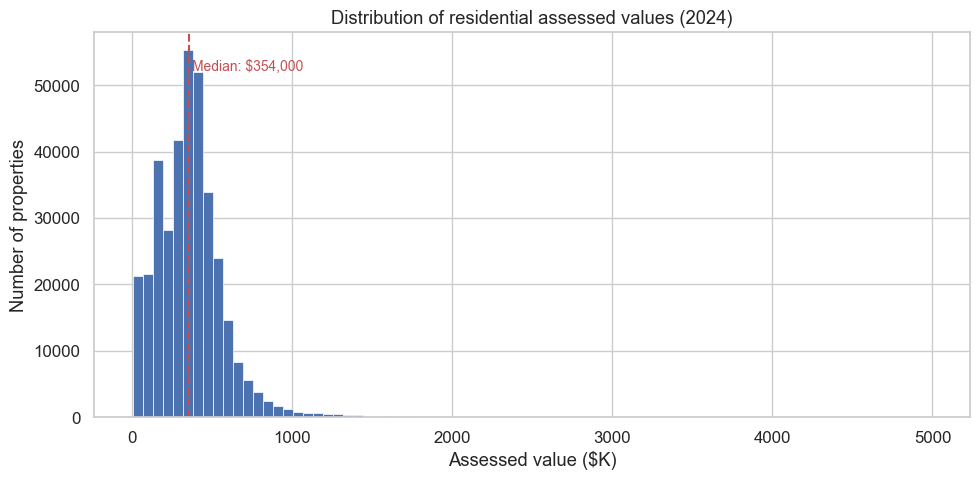

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df_2024["assessed_value"] / 1000,
    bins=80,
    edgecolor="white",
    linewidth=0.5,
    color="#4C72B0",
)
ax.set_xlabel("Assessed value ($K)")
ax.set_ylabel("Number of properties")
ax.set_title("Distribution of residential assessed values (2024)")

# Add median line
median_val = df_2024["assessed_value"].median()
ax.axvline(median_val / 1000, color="#C44E52", linestyle="--", linewidth=1.5)
ax.text(
    median_val / 1000 + 20, ax.get_ylim()[1] * 0.9,
    f"Median: ${median_val:,.0f}",
    color="#C44E52", fontsize=10,
)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/01_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The distribution is right-skewed with a median assessed value of $354,000.
The bulk of residential properties fall between $100K and $600K, with a long
tail extending to $5M. The right skew means the mean ($367K) is pulled higher
than the median by expensive properties, making median the better measure of
a "typical" Edmonton residential property.

In [17]:
print("Assessed value summary (2024):")
print(df_2024["assessed_value"].describe().apply(lambda x: f"${x:,.0f}"))

Assessed value summary (2024):
count      $359,998
mean       $366,883
std        $239,085
min         $10,000
25%        $216,000
50%        $354,000
75%        $463,000
max      $4,988,000
Name: assessed_value, dtype: str


### 3.2 Top and bottom neighbourhoods by median assessed value

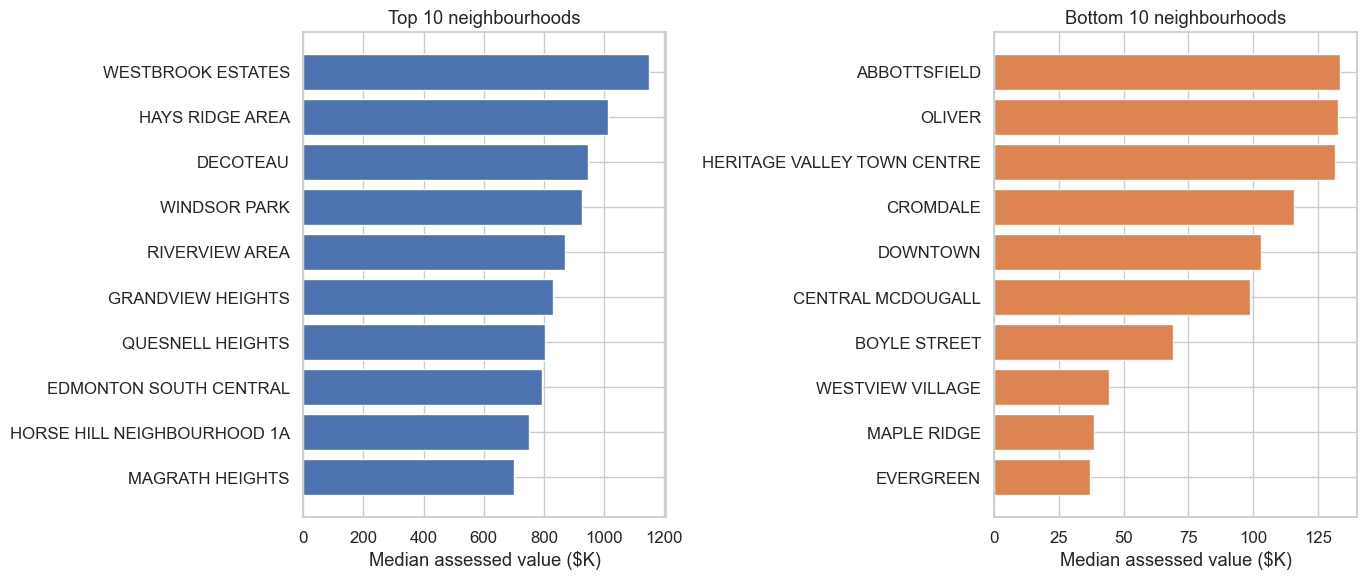

In [18]:
neighbourhood_medians = (
    df_2024
    .groupby("neighbourhood_name")["assessed_value"]
    .agg(["median", "count"])
    .rename(columns={"median": "median_value", "count": "property_count"})
    .query("property_count >= 50")  # Only neighbourhoods with enough data
    .sort_values("median_value", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10
top_10 = neighbourhood_medians.head(10)
axes[0].barh(top_10.index[::-1], top_10["median_value"][::-1] / 1000, color="#4C72B0")
axes[0].set_xlabel("Median assessed value ($K)")
axes[0].set_title("Top 10 neighbourhoods")

# Bottom 10
bottom_10 = neighbourhood_medians.tail(10)
axes[1].barh(bottom_10.index[::-1], bottom_10["median_value"][::-1] / 1000, color="#DD8452")
axes[1].set_xlabel("Median assessed value ($K)")
axes[1].set_title("Bottom 10 neighbourhoods")

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/02_neighbourhood_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The gap between Edmonton's highest and lowest assessed neighbourhoods is
roughly 10x. Westbrook Estates leads at ~$1.1M median, while the bottom
neighbourhoods sit between $25K-$130K.

The bottom 10 list is revealing: Oliver, Downtown, Central McDougall, and
Heritage Valley Town Centre are all condo-heavy areas. Their low median
values reflect the fact that individual condo units are assessed much lower
than detached homes, not that the neighbourhoods are undesirable. Westview
Village, Maple Ridge, and Evergreen at the very bottom ($25-40K) likely
consist of small, older units or manufactured housing.

The top 10 are established single-family neighbourhoods with large lots:
Westbrook Estates, Hays Ridge Area, Windsor Park, Riverview Area, and
Quesnell Heights are all known for larger properties near the river valley
or in newer southwest developments.

This 10x spread across neighbourhoods is a key reason why location
(neighbourhood, lat/lon) will be an important feature in the regression model.

### 3.3 Assessed value by zoning category

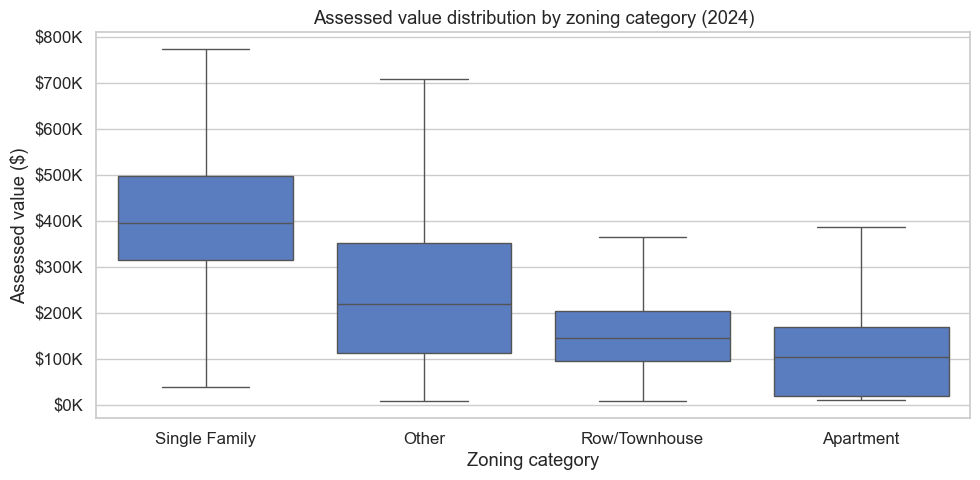

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

zoning_order = (
    df_2024.groupby("zoning_group")["assessed_value"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df_2024,
    x="zoning_group",
    y="assessed_value",
    order=zoning_order,
    showfliers=False,  # Hide outlier dots for readability
    ax=ax,
)
ax.set_ylabel("Assessed value ($)")
ax.set_xlabel("Zoning category")
ax.set_title("Assessed value distribution by zoning category (2024)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/03_zoning_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Single family properties have the highest median assessed value (~$400K),
followed by the "Other" catch-all category (~$220K, which includes direct
control zones and mixed-use), row/townhouse (~$150K), and apartments (~$100K).

This ordering is expected: single family homes sit on individual lots,
which are inherently more valuable than individual units in multi-unit
buildings. The value difference between categories is driven primarily by
lot size and building type, not by the zoning label itself.

The wide spread within each category (especially Single Family and Other)
indicates that zoning alone does not determine value. Location, lot size,
and property age create substantial variation within each group.

### 3.4 Garage vs no garage comparison

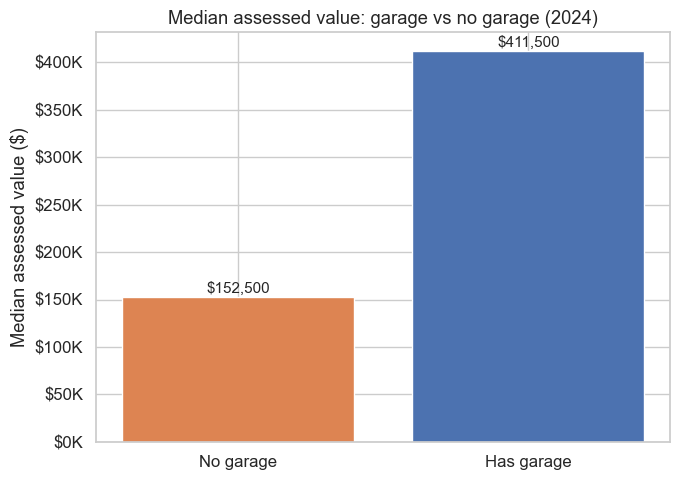

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

garage_stats = df_2024.groupby("has_garage")["assessed_value"].agg(["mean", "median", "count"])
garage_stats.index = ["No garage", "Has garage"]

bars = ax.bar(garage_stats.index, garage_stats["median"], color=["#DD8452", "#4C72B0"])

# Add value labels on bars
for bar, val in zip(bars, garage_stats["median"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
        f"${val:,.0f}", ha="center", fontsize=11,
    )

ax.set_ylabel("Median assessed value ($)")
ax.set_title("Median assessed value: garage vs no garage (2024)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/04_garage_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Properties with garages have a median assessed value of $411,500 compared
to $152,500 for those without, a difference of $259,000.

However, this gap does not mean a garage "adds" $259K to a property. The
garage variable is heavily confounded with property type: nearly all single
family detached homes have garages, while most condos and apartments do
not. The "garage premium" is largely a proxy for the difference between
houses and multi-unit properties. The t-test in Section 4 will quantify
this difference formally, but the causal interpretation remains limited.

### 3.5 Spatial distribution of property values

A scatter plot of latitude and longitude, colored by assessed value, to
visualize geographic patterns across the city.

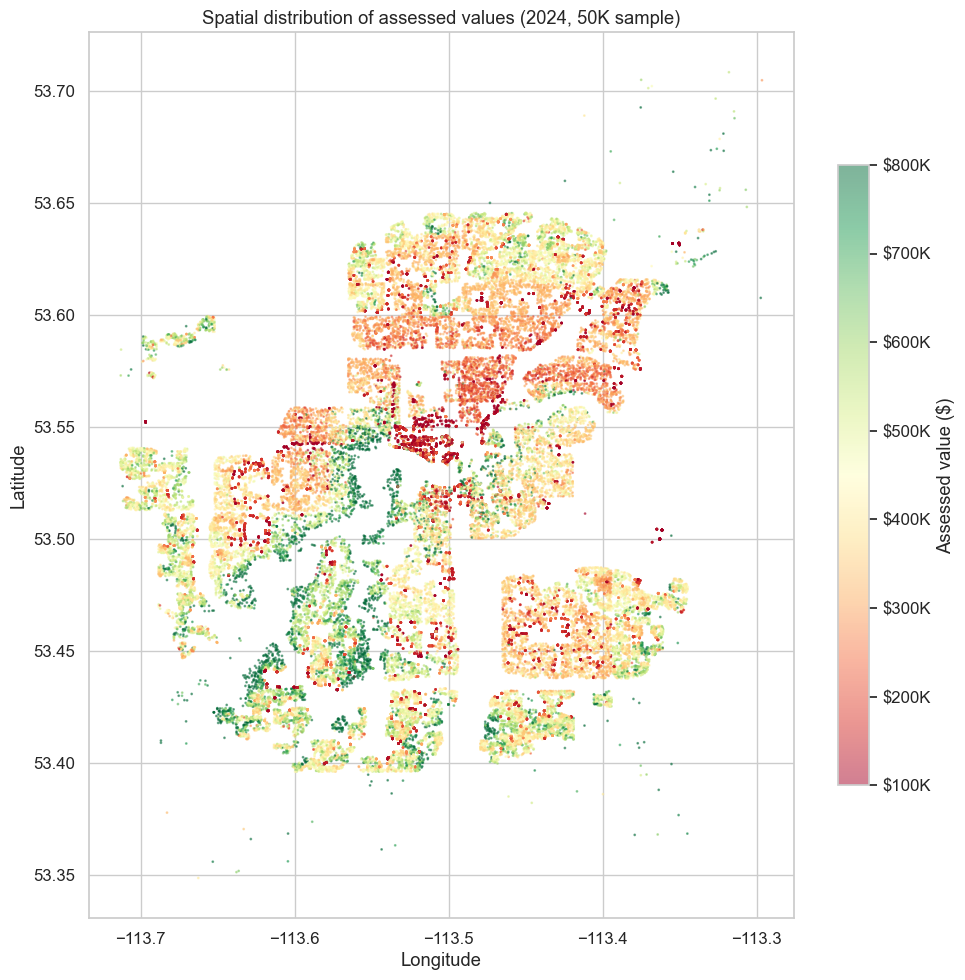

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

# Sample for performance (plotting 400K points is slow)
sample = df_2024.dropna(subset=["latitude", "longitude"]).sample(
    n=min(50_000, len(df_2024)), random_state=RANDOM_STATE
)

scatter = ax.scatter(
    sample["longitude"],
    sample["latitude"],
    c=sample["assessed_value"],
    cmap="RdYlGn",
    s=1,
    alpha=0.5,
    vmin=100_000,
    vmax=800_000,
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Assessed value ($)")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial distribution of assessed values (2024, 50K sample)")

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/05_spatial_values.png", dpi=150, bbox_inches="tight")
plt.show()

The spatial map reveals distinct geographic patterns in Edmonton's property
values:

- **Southwest (bottom-left):** Strong clusters of green ($500K-$800K+),
  corresponding to newer suburban developments like Windermere, Magrath
  Heights, and Keswick.
- **Central core (around 53.54, -113.50):** Dense red/pink clusters
  ($100K-$200K), reflecting the concentration of condos and apartments in
  Downtown, Oliver, and surrounding inner-city neighbourhoods.
- **West side:** Pockets of green along the river valley corridor (Riverview,
  Quesnell Heights, Grandview Heights), consistent with the top 10
  neighbourhood rankings.
- **North:** Mixed yellow-orange ($300K-$400K), more uniform than the south.

The pattern confirms that location is a major driver of assessed value
and supports the inclusion of latitude/longitude as features in the
regression model. The visible clustering also explains why neighbourhood
name alone captures so much variation: properties within the same
neighbourhood tend to have similar values.

<a id="4-statistical-hypothesis-testing"></a>
## 4. Statistical hypothesis testing

Four formal tests to quantify relationships observed in the EDA. Each test
includes the null/alternative hypothesis, test statistic, p-value,
confidence interval, and effect size.

**Reminder:** All tests measure statistical association. With n > 300K,
nearly everything will be "statistically significant." Effect sizes and
confidence intervals tell us whether the difference is practically
meaningful.

### 4.1 Test 1: Garage premium (independent samples t-test)

**H0:** Mean assessed value of properties with garages = without garages.

**H1:** Mean assessed value of properties with garages ≠ without garages.

In [22]:
def cohens_d(group_a: pd.Series, group_b: pd.Series) -> float:
    """Calculate Cohen's d effect size for two independent groups."""
    n_a, n_b = len(group_a), len(group_b)
    var_a, var_b = group_a.var(), group_b.var()
    pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    return (group_a.mean() - group_b.mean()) / pooled_std


garage_yes = df_2024[df_2024["has_garage"] == True]["assessed_value"]
garage_no = df_2024[df_2024["has_garage"] == False]["assessed_value"]

t_stat, p_value = ttest_ind(garage_yes, garage_no, equal_var=False)
effect_size = cohens_d(garage_yes, garage_no)
mean_diff = garage_yes.mean() - garage_no.mean()

# 95% confidence interval for the difference in means
se_diff = np.sqrt(garage_yes.var() / len(garage_yes) + garage_no.var() / len(garage_no))
ci_lower = mean_diff - 1.96 * se_diff
ci_upper = mean_diff + 1.96 * se_diff

print("=" * 60)
print("TEST 1: Garage Premium (Independent Samples t-test)")
print("=" * 60)
print(f"  Garage mean:      ${garage_yes.mean():>12,.0f}  (n = {len(garage_yes):,})")
print(f"  No garage mean:   ${garage_no.mean():>12,.0f}  (n = {len(garage_no):,})")
print(f"  Difference:       ${mean_diff:>12,.0f}")
print(f"  95% CI:           (${ci_lower:,.0f} to ${ci_upper:,.0f})")
print(f"  t-statistic:      {t_stat:>12.2f}")
print(f"  p-value:          {p_value:>12.2e}")
print(f"  Cohen's d:        {effect_size:>12.3f}")
print()

if p_value < 0.05:
    print(f"  Result: REJECT H0. Properties with garages are assessed")
    print(f"  ${mean_diff:,.0f} higher on average (p < 0.001).")
    print(f"  Effect size is {'small' if abs(effect_size) < 0.5 else 'medium' if abs(effect_size) < 0.8 else 'large'} (d = {effect_size:.3f}).")
else:
    print("  Result: FAIL TO REJECT H0. No significant difference found.")

TEST 1: Garage Premium (Independent Samples t-test)
  Garage mean:      $     455,166  (n = 249,103)
  No garage mean:   $     168,572  (n = 110,895)
  Difference:       $     286,594
  95% CI:           ($285,436 to $287,752)
  t-statistic:            485.15
  p-value:              0.00e+00
  Cohen's d:               1.439

  Result: REJECT H0. Properties with garages are assessed
  $286,594 higher on average (p < 0.001).
  Effect size is large (d = 1.439).


**Interpretation:**

The difference is statistically significant (p < 0.001) with a large effect
size (Cohen's d = 1.44). Properties with garages are assessed $286,594 higher
on average, with a tight 95% confidence interval ($285K-$288K).

However, this result requires careful framing. The t-statistic of 485 is
astronomically high, which is expected with n = 360,000. At this sample size,
even trivial differences become "statistically significant." This is why the
effect size and confidence interval matter more than the p-value here.

More importantly, the $287K gap is not the "value of a garage." It is the
difference between two fundamentally different property populations:
- Properties WITH garages are predominantly single-family detached homes
  on individual lots (mean $455K)
- Properties WITHOUT garages are predominantly condos, apartments, and
  older inner-city units (mean $169K)

The garage variable acts as a proxy for property type. A more precise
estimate of the garage's independent contribution would require controlling
for property type, lot size, and location, which is addressed in the
multiple regression in Section 5.

### 4.2 Test 2: Zoning category differences (one-way ANOVA + Tukey HSD)

**H0:** Mean assessed value is the same across all zoning categories.

**H1:** At least one zoning category has a significantly different mean.

In [23]:
from scipy.stats import tukey_hsd

# Prepare groups (exclude "Other" and "Commercial" for cleaner residential comparison)
residential_zonings = ["Single Family", "Row/Townhouse", "Apartment"]
zoning_groups = [
    df_2024[df_2024["zoning_group"] == z]["assessed_value"].values
    for z in residential_zonings
]

f_stat, p_value_anova = f_oneway(*zoning_groups)

print("=" * 60)
print("TEST 2: Zoning Category Differences (One-Way ANOVA)")
print("=" * 60)
print(f"  Groups: {residential_zonings}")
for name, group in zip(residential_zonings, zoning_groups):
    print(f"  {name:<20s}  mean: ${np.mean(group):>10,.0f}  (n = {len(group):,})")
print(f"  F-statistic:      {f_stat:>12.2f}")
print(f"  p-value:          {p_value_anova:>12.2e}")
print()

if p_value_anova < 0.05:
    print("  Result: REJECT H0. At least one zoning category differs.")
    print()

    # Tukey HSD post-hoc
    tukey_result = tukey_hsd(*zoning_groups)
    print("  Tukey HSD pairwise comparisons:")
    for i in range(len(residential_zonings)):
        for j in range(i + 1, len(residential_zonings)):
            p_adj = tukey_result.pvalue[i][j]
            diff = np.mean(zoning_groups[i]) - np.mean(zoning_groups[j])
            sig = "***" if p_adj < 0.001 else "**" if p_adj < 0.01 else "*" if p_adj < 0.05 else "ns"
            print(f"    {residential_zonings[i]} vs {residential_zonings[j]}: "
                  f"diff = ${diff:>+10,.0f}, p = {p_adj:.4f} {sig}")

TEST 2: Zoning Category Differences (One-Way ANOVA)
  Groups: ['Single Family', 'Row/Townhouse', 'Apartment']
  Single Family         mean: $   425,164  (n = 266,170)
  Row/Townhouse         mean: $   164,865  (n = 53,432)
  Apartment             mean: $   118,451  (n = 2,540)
  F-statistic:          35435.64
  p-value:              0.00e+00

  Result: REJECT H0. At least one zoning category differs.

  Tukey HSD pairwise comparisons:
    Single Family vs Row/Townhouse: diff = $  +260,299, p = 0.0000 ***
    Single Family vs Apartment: diff = $  +306,713, p = 0.0000 ***
    Row/Townhouse vs Apartment: diff = $   +46,414, p = 0.0000 ***


**Interpretation:**

All three residential zoning categories have significantly different mean
assessed values (F = 35,436, p < 0.001). Tukey HSD confirms every pairwise
comparison is significant at p < 0.001:

- Single Family ($425K) vs Row/Townhouse ($165K): $260K difference
- Single Family ($425K) vs Apartment ($118K): $307K difference
- Row/Townhouse ($165K) vs Apartment ($118K): $46K difference

The ordering is intuitive: single family homes sit on dedicated lots with
more land and living space, row housing shares walls but often has its own
lot, and apartment units are individual portions of larger buildings.

As with the garage test, these differences are driven by fundamental
property characteristics (lot size, building footprint) that are inherent
to each zoning type, not by the zoning label itself. Rezoning a single
family lot to apartment zoning would not reduce its assessed value by $307K.
The zoning reflects what was built, and what was built determines the value.

Note: The Apartment group (n = 2,540) is smaller than the other two because
many apartment-zoned properties in Edmonton use Direct Control (DC1/DC2)
zoning codes, which are grouped under "Other" since their actual use varies.

### 4.3 Test 3: Appreciation rate differences by geographic zone

Instead of an arbitrary chi-square bin test, this test asks a more natural
question: **Do different parts of the city appreciate at different rates?**

Properties are split into geographic quadrants (NW, NE, SW, SE) using the
city centroid as the dividing point. A one-way ANOVA tests whether the mean
appreciation rate differs across quadrants.

**H0:** Mean 2022-2024 appreciation rate is the same across all quadrants.

**H1:** At least one quadrant has a significantly different appreciation rate.

In [24]:
# Build the appreciation dataset by joining 2022 and 2024 on account_number
df_2022 = df[df["assessment_year"] == 2022][["account_number", "assessed_value", "latitude", "longitude", "neighbourhood_name"]].copy()
df_2024_join = df[df["assessment_year"] == 2024][["account_number", "assessed_value"]].copy()

df_appreciation = df_2022.merge(
    df_2024_join,
    on="account_number",
    suffixes=("_2022", "_2024"),
)

# Calculate percentage change
df_appreciation["pct_change"] = (
    (df_appreciation["assessed_value_2024"] - df_appreciation["assessed_value_2022"])
    / df_appreciation["assessed_value_2022"]
    * 100
)

# Remove extreme appreciation values (data entry errors, major renovations)
df_appreciation = df_appreciation[
    (df_appreciation["pct_change"] > -50) & (df_appreciation["pct_change"] < 100)
].copy()

print(f"Matched properties (2022 to 2024): {len(df_appreciation):,}")

Matched properties (2022 to 2024): 348,700


In [25]:
# Assign geographic quadrants based on city centroid
city_lat = df_appreciation["latitude"].median()
city_lon = df_appreciation["longitude"].median()

def assign_quadrant(row: pd.Series) -> str:
    """Assign a property to a geographic quadrant based on lat/lon."""
    north = row["latitude"] >= city_lat
    west = row["longitude"] <= city_lon
    if north and west:
        return "Northwest"
    elif north and not west:
        return "Northeast"
    elif not north and west:
        return "Southwest"
    else:
        return "Southeast"


df_appreciation["quadrant"] = df_appreciation.apply(assign_quadrant, axis=1)

# Run ANOVA on appreciation rates by quadrant
quadrant_names = ["Northwest", "Northeast", "Southwest", "Southeast"]
quadrant_groups = [
    df_appreciation[df_appreciation["quadrant"] == q]["pct_change"].values
    for q in quadrant_names
]

f_stat_q, p_value_q = f_oneway(*quadrant_groups)

print("=" * 60)
print("TEST 3: Appreciation Rate by Geographic Quadrant (ANOVA)")
print("=" * 60)
for name, group in zip(quadrant_names, quadrant_groups):
    print(f"  {name:<15s}  mean: {np.mean(group):>+6.2f}%  median: {np.median(group):>+6.2f}%  (n = {len(group):,})")
print(f"  F-statistic:      {f_stat_q:>12.2f}")
print(f"  p-value:          {p_value_q:>12.2e}")
print()

if p_value_q < 0.05:
    print("  Result: REJECT H0. Appreciation rates differ significantly by quadrant.")
else:
    print("  Result: FAIL TO REJECT H0. No significant difference across quadrants.")

TEST 3: Appreciation Rate by Geographic Quadrant (ANOVA)
  Northwest        mean:  +0.10%  median:  -0.48%  (n = 73,436)
  Northeast        mean:  -0.59%  median:  -0.43%  (n = 100,916)
  Southwest        mean:  +4.77%  median:  +6.05%  (n = 101,172)
  Southeast        mean:  +4.80%  median:  +6.38%  (n = 73,176)
  F-statistic:          12809.15
  p-value:              0.00e+00

  Result: REJECT H0. Appreciation rates differ significantly by quadrant.


**Interpretation:**

There is a stark north-south divide in Edmonton's property appreciation
between 2022 and 2024:

- **South appreciated:** Southwest (+6.1% median) and Southeast (+6.4% median)
  both saw strong positive growth.
- **North was flat or declining:** Northwest (-0.5% median) and Northeast
  (-0.4% median) effectively stagnated.

The difference is highly significant (F = 12,809, p < 0.001) and, unlike
the garage or zoning tests, the effect here is not an artifact of property
type mixing. This is a genuine geographic pattern: properties in south
Edmonton gained roughly 6-7 percentage points more than those in the north
over two years.

Possible explanations (not testable with this data alone):
- Newer suburban developments in the south (Windermere, Keswick, Heritage
  Valley) attracting buyer demand
- Proximity to the Henday and newer commercial development in the southwest
- Aging housing stock in parts of north Edmonton suppressing appreciation

Note that the mean and median diverge in the north quadrants (NW mean +0.1%
vs median -0.5%), suggesting a few high-appreciation outliers are pulling
the mean up while the typical property actually lost value.

This finding would be directly actionable for a real estate investor or
city planner evaluating where growth is concentrated.

### 4.4 Test 4: Property age vs assessed value (simple linear regression)

**H0:** Property age has no linear relationship with assessed value (slope = 0).

**H1:** Property age has a significant linear relationship with assessed value.

This test is expected to show a weak or non-linear relationship, since newer
properties are built in different (possibly more desirable) areas than older
ones. The result itself is informative.

In [26]:
# Filter to properties with reasonable age (0 to 120 years)
age_df = df_2024[(df_2024["property_age"] >= 0) & (df_2024["property_age"] <= 120)].copy()

slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
    age_df["property_age"], age_df["assessed_value"]
)

print("=" * 60)
print("TEST 4: Property Age vs Assessed Value (Linear Regression)")
print("=" * 60)
print(f"  Slope:            ${slope:>12,.2f} per year of age")
print(f"  Intercept:        ${intercept:>12,.0f}")
print(f"  R-squared:        {r_value**2:>12.4f}")
print(f"  p-value:          {p_value_reg:>12.2e}")
print()
print(f"  Interpretation: Each additional year of property age is")
print(f"  associated with a ${slope:,.0f} change in assessed value.")
print(f"  However, R-squared of {r_value**2:.4f} indicates that age alone")
print(f"  explains only {r_value**2 * 100:.1f}% of the variance in assessed value.")

TEST 4: Property Age vs Assessed Value (Linear Regression)
  Slope:            $   -1,758.51 per year of age
  Intercept:        $     425,248
  R-squared:              0.0290
  p-value:              0.00e+00

  Interpretation: Each additional year of property age is
  associated with a $-1,759 change in assessed value.
  However, R-squared of 0.0290 indicates that age alone
  explains only 2.9% of the variance in assessed value.


**Interpretation:**

Property age is statistically significant (p < 0.001) but practically
a very weak predictor of assessed value, explaining only 2.9% of variance.

The slope of -$1,759 per year means a 50-year-old home is associated with
roughly $88K less assessed value than a brand-new home, all else being equal.
But "all else" is NOT equal: newer homes are concentrated in south Edmonton's
higher-value suburbs while older homes are spread across the city, including
lower-value areas. The age coefficient is absorbing location effects.

The scatter plot below confirms this visually: there is enormous variance
at every age. A 10-year-old property can be assessed anywhere from $50K to
$2M+. Age alone tells you almost nothing about a specific property's value.

This is actually an important finding: it demonstrates that simple
single-variable relationships can be misleading and that multivariate
analysis (Section 5) is necessary to isolate individual contributions.

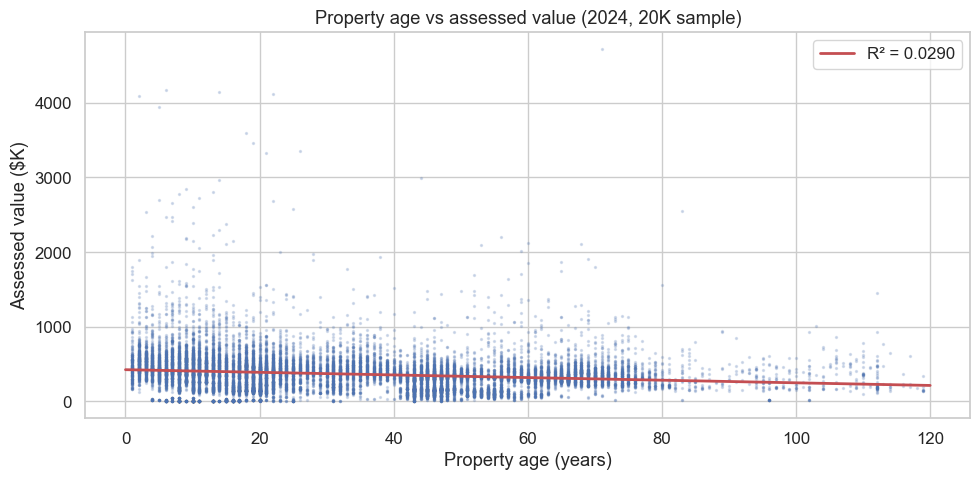

In [27]:
# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(10, 5))

# Sample for readability
sample = age_df.sample(n=min(20_000, len(age_df)), random_state=RANDOM_STATE)
ax.scatter(sample["property_age"], sample["assessed_value"] / 1000, s=2, alpha=0.2, color="#4C72B0")

# Regression line
x_line = np.linspace(0, 120, 100)
y_line = (slope * x_line + intercept) / 1000
ax.plot(x_line, y_line, color="#C44E52", linewidth=2, label=f"R² = {r_value**2:.4f}")

ax.set_xlabel("Property age (years)")
ax.set_ylabel("Assessed value ($K)")
ax.set_title("Property age vs assessed value (2024, 20K sample)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/06_age_vs_value.png", dpi=150, bbox_inches="tight")
plt.show()

<a id="5-multiple-regression-analysis"></a>
## 5. Multiple regression analysis

A multiple linear regression model to estimate the relative contribution
of each observable feature to assessed value. This is an **inference
model**, not a prediction model. The goal is to understand which features
explain the most variance, not to achieve the highest accuracy.

**Features:** property_age, lot_size, has_garage, zoning_group (one-hot),
latitude, longitude.

**Target:** assessed_value.

**Important caveat:** These coefficients represent associations after
controlling for the other variables in the model. They do not establish
causal relationships due to omitted variable bias (missing: square footage,
bedrooms, property condition).

**Preparing the regression dataset**

The regression requires non-null lot_size, which reduces the 2024 dataset
from 360K to 243K rows (67% retention). The missing lot_size values are
concentrated in 2024 due to a data collection change by the city. This means
the regression results apply to the subset of properties with recorded lot
sizes and may not fully represent condo-heavy neighbourhoods where lot_size
is more commonly missing.


**DATA COVERAGE NOTE:**
 
Validation testing (Section 8) confirmed that the
regression dataset is 95% single family homes. Properties without lot_size
are predominantly row/townhouse (44%) and other (25%) categories. This means
the regression coefficients primarily reflect value drivers within the single
family segment, not across all property types. The t-test, ANOVA, and
appreciation analyses are not affected by this limitation since they do not
depend on lot_size.

In [28]:
# Prepare the regression dataset (2024 snapshot, no nulls in lot_size)
reg_df = df_2024.dropna(subset=["lot_size"]).copy()
reg_df = reg_df[reg_df["lot_size"] > 0].copy()
reg_df = reg_df[(reg_df["property_age"] >= 0) & (reg_df["property_age"] <= 120)].copy()
print(f"Regression dataset: {len(reg_df):,} rows")

Regression dataset: 242,727 rows


In [29]:
# Encode categorical variable (zoning_group)
# Use top 3 residential categories, drop "Other" as reference
zoning_dummies = pd.get_dummies(
    reg_df["zoning_group"], prefix="zoning", drop_first=False
)
# Keep only the meaningful categories
zoning_cols_to_keep = [c for c in zoning_dummies.columns if c != "zoning_Other"]
zoning_dummies = zoning_dummies[zoning_cols_to_keep]

# Build feature matrix
feature_cols = ["property_age", "lot_size", "has_garage", "latitude", "longitude"]
X = reg_df[feature_cols].copy()
X["has_garage"] = X["has_garage"].astype(int)
X = pd.concat([X, zoning_dummies], axis=1)

y = reg_df["assessed_value"].values

print(f"Features: {list(X.columns)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features: ['property_age', 'lot_size', 'has_garage', 'latitude', 'longitude', 'zoning_Apartment', 'zoning_Row/Townhouse', 'zoning_Single Family']
X shape: (242727, 8), y shape: (242727,)


### 5.1 Fit the model

In [30]:
print(X.dtypes)
print()
print(X.head())

property_age              int64
lot_size                float64
has_garage                int64
latitude                float64
longitude               float64
zoning_Apartment           bool
zoning_Row/Townhouse       bool
zoning_Single Family       bool
dtype: object

        property_age  lot_size  has_garage  latitude  longitude  \
844710            21    396.00           1     53.64    -113.51   
844711            21    365.00           1     53.64    -113.51   
844712            21    365.00           1     53.64    -113.51   
844713            21    425.00           1     53.64    -113.51   
844714            21    551.00           1     53.64    -113.51   

        zoning_Apartment  zoning_Row/Townhouse  zoning_Single Family  
844710             False                 False                  True  
844711             False                 False                  True  
844712             False                 False                  True  
844713             False                 F

In [31]:
# Convert boolean columns to int (statsmodels requires numeric types)
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [32]:
# Using statsmodels OLS for detailed summary (p-values per coefficient)
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     5746.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        14:43:03   Log-Likelihood:            -3.3135e+06
No. Observations:              242727   AIC:                         6.627e+06
Df Residuals:                  242718   BIC:                         6.627e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -1.748e+07 

**Interpretation:**

The model explains 15.9% of the variance in assessed value using 8 externally
observable features. While this may appear low, it is expected given that the
most important drivers of individual property value (square footage, number
of bedrooms/bathrooms, interior condition) are not available in the public
assessment data.

**Significant features (p < 0.001):**
- `has_garage`: +$116,200. After controlling for lot size, age, zoning, and
  location, properties with garages are still assessed $116K higher. This is
  substantially less than the raw $287K gap from Test 1, confirming that much
  of the garage "premium" was actually driven by property type and location
  differences.
- `latitude`: -$374,500 per degree. Moving one degree north (roughly 111 km)
  is associated with a $375K decrease. This captures the south-is-higher-value
  pattern visible in the spatial map.
- `longitude`: -$334,300 per degree. Moving one degree east is associated with
  a $334K decrease. Combined with latitude, these two features encode the
  geographic premium.
- `property_age`: -$2,284 per year. Consistent with Test 4, each year of age
  reduces assessed value by about $2,300 after controlling for other features.
- `lot_size`: +$1.42 per square foot. Modest but significant.
- `zoning_Apartment`: +$328K relative to "Other" (the reference category).
- `zoning_Row/Townhouse`: +$130K relative to "Other."

**Not significant:**
- `zoning_Single Family`: +$2,082 (p = 0.357). Single family properties are
  not significantly different from the "Other" reference group after
  controlling for lot size, garage, age, and location. This makes sense:
  once you account for the fact that single family homes have larger lots
  and garages, the zoning label itself adds little.

**Key takeaway:** The garage coefficient dropped from $287K (raw t-test) to
$116K (regression). This demonstrates why multivariate analysis matters:
controlling for confounders reveals that more than half of the apparent
garage premium was actually driven by lot size, zoning, and location
differences between garage and non-garage properties.

**Condition number warning:** The large condition number (1.74e+07) indicates
multicollinearity, primarily between latitude and longitude. This is addressed
in the VIF analysis below.

### 5.2 Coefficient interpretation

In [33]:
coef_df = pd.DataFrame({
    "feature": ["intercept"] + list(X.columns),
    "coefficient": ols_model.params,
    "std_error": ols_model.bse,
    "p_value": ols_model.pvalues,
}).set_index("feature")

# Sort by absolute coefficient magnitude (exclude intercept)
coef_display = coef_df.drop("intercept").copy()
coef_display["abs_coef"] = coef_display["coefficient"].abs()
coef_display = coef_display.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("Regression coefficients (sorted by magnitude):")
print()
for idx, row in coef_display.iterrows():
    sig = "***" if row["p_value"] < 0.001 else "ns"
    print(f"  {idx:<30s}  coef: {row['coefficient']:>+12,.2f}  (p {sig})")

print(f"\n  R-squared: {ols_model.rsquared:.4f}")
print(f"  Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"\n  The model explains {ols_model.rsquared * 100:.1f}% of the variance in")
print(f"  assessed value using only externally observable features.")
print(f"  The remaining {(1 - ols_model.rsquared) * 100:.1f}% is likely explained by interior")
print(f"  property characteristics not available in the public data.")

Regression coefficients (sorted by magnitude):

  latitude                        coef:  -374,505.81  (p ***)
  longitude                       coef:  -334,313.12  (p ***)
  zoning_Apartment                coef:  +327,760.37  (p ***)
  zoning_Row/Townhouse            coef:  +129,532.92  (p ***)
  has_garage                      coef:  +116,221.26  (p ***)
  property_age                    coef:    -2,283.65  (p ***)
  zoning_Single Family            coef:    +2,081.83  (p ns)
  lot_size                        coef:        +1.42  (p ***)

  R-squared: 0.1592
  Adjusted R-squared: 0.1592

  The model explains 15.9% of the variance in
  assessed value using only externally observable features.
  The remaining 84.1% is likely explained by interior
  property characteristics not available in the public data.


### 5.3 Regression diagnostics

Checking model assumptions: residual distribution, homoscedasticity, and
multicollinearity (VIF).

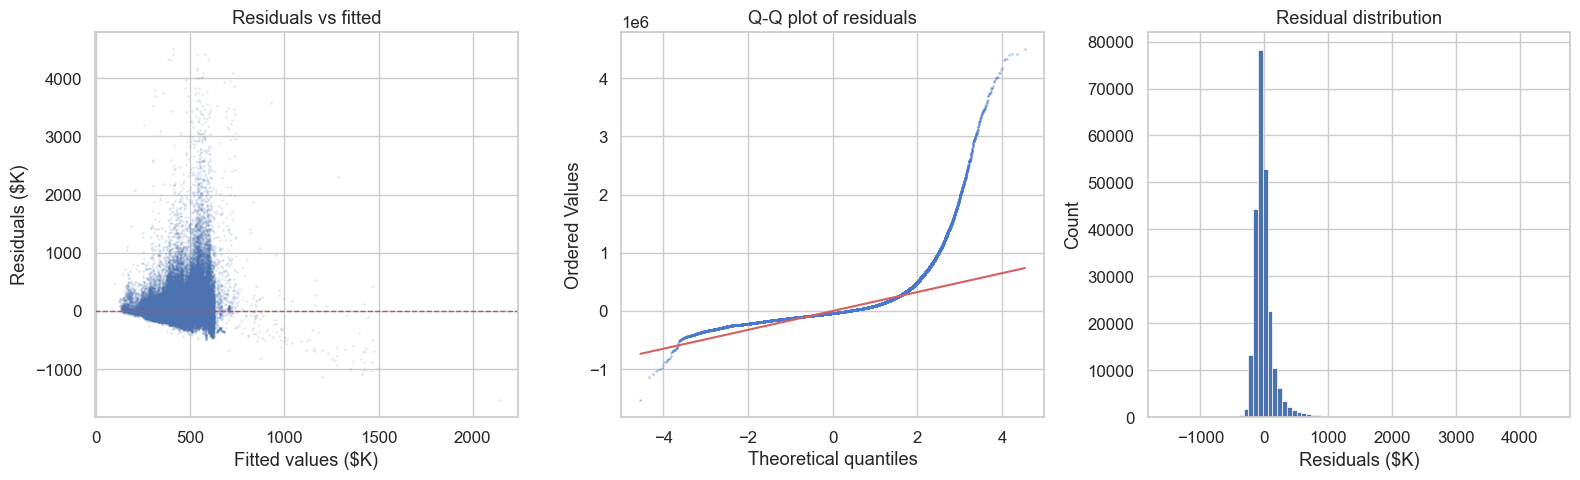

In [34]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs fitted values
axes[0].scatter(fitted / 1000, residuals / 1000, s=1, alpha=0.1, color="#4C72B0")
axes[0].axhline(0, color="#C44E52", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values ($K)")
axes[0].set_ylabel("Residuals ($K)")
axes[0].set_title("Residuals vs fitted")

# 2. Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of residuals")
axes[1].get_lines()[0].set_markersize(1)
axes[1].get_lines()[0].set_alpha(0.3)

# 3. Residual distribution
axes[2].hist(residuals / 1000, bins=80, edgecolor="white", linewidth=0.5, color="#4C72B0")
axes[2].set_xlabel("Residuals ($K)")
axes[2].set_ylabel("Count")
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/07_regression_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

**Regression diagnostics:**

- **Residuals vs fitted (left):** The residuals show a fan shape, widening as
  fitted values increase. This indicates heteroscedasticity: the model's
  prediction errors are larger for higher-value properties. This is common
  in property value models since expensive homes have more variability.

- **Q-Q plot (center):** The residuals deviate sharply from normal in the
  upper tail, curving upward. This means the model systematically
  underpredicts high-value properties. The lower tail is closer to normal.

- **Residual distribution (right):** Heavily right-skewed. Most residuals
  cluster near zero (the model does well for typical properties) but there
  is a long positive tail (expensive properties the model cannot capture
  with external features alone).

**What this means:** The linear regression assumptions of normality and
constant variance are violated. This does not invalidate the coefficient
interpretations for typical properties, but it means the model performs
poorly at the high end. A log-transformation of assessed_value would
likely improve the fit, but is kept out of scope to maintain
interpretability of the coefficients in dollar terms.

In [35]:
# Variance Inflation Factor (VIF) to check multicollinearity
# VIF > 10 indicates problematic multicollinearity
vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors:")
print()
for _, row in vif_data.iterrows():
    flag = " ⚠ HIGH" if row["VIF"] > 10 else ""
    print(f"  {row['feature']:<30s}  VIF: {row['VIF']:>8.2f}{flag}")

Variance Inflation Factors:

  latitude                        VIF: 411484.82 ⚠ HIGH
  longitude                       VIF: 410793.59 ⚠ HIGH
  zoning_Single Family            VIF:    27.96 ⚠ HIGH
  has_garage                      VIF:    15.58 ⚠ HIGH
  property_age                    VIF:     3.43
  zoning_Row/Townhouse            VIF:     1.31
  lot_size                        VIF:     1.03
  zoning_Apartment                VIF:     1.00


**Multicollinearity check (VIF):**

- **Latitude and longitude (VIF > 400K):** Extremely high, but this is a
  known artifact of using raw geographic coordinates as separate features.
  Latitude and longitude together define a 2D location; neither is meaningful
  alone. Their individual coefficients are unstable (small data changes could
  flip the magnitudes), but the model's overall R-squared and the other
  coefficients remain valid. An alternative approach would be to use
  neighbourhood as a categorical variable, but that would create 300+ dummy
  columns.

- **zoning_Single Family (VIF = 28) and has_garage (VIF = 16):** Moderately
  high. These are correlated because most single family properties have
  garages. This explains why zoning_Single Family is not significant
  (p = 0.357) in the regression: once has_garage, lot_size, and location
  are in the model, the single family zoning label adds no independent
  information.

- **property_age (VIF = 3.4), lot_size (1.0), zoning_Row/Townhouse (1.3),
  zoning_Apartment (1.0):** All below 5, no multicollinearity concern.
  Their coefficients are reliable.

**Summary:** The high VIF on lat/lon is expected and acceptable for an
inference model. The garage-zoning correlation is a real confounding
relationship in the data, not a modeling error. No features need to be
removed.

<a id="6-year-over-year-appreciation-analysis"></a>
## 6. Year-over-year appreciation analysis

Tracking how property values changed from 2022 to 2024 at the property
level (joined on `account_number`) and aggregated by neighbourhood and
zoning category.

### 6.1 Citywide appreciation summary

In [36]:
print("=" * 60)
print("CITYWIDE APPRECIATION: 2022 to 2024")
print("=" * 60)
print(f"  Matched properties:     {len(df_appreciation):,}")
print(f"  Mean appreciation:      {df_appreciation['pct_change'].mean():>+.2f}%")
print(f"  Median appreciation:    {df_appreciation['pct_change'].median():>+.2f}%")
print(f"  Std deviation:          {df_appreciation['pct_change'].std():>.2f}%")

# One-sample t-test: is the mean appreciation significantly different from 0?
t_stat_city, p_value_city = stats.ttest_1samp(df_appreciation["pct_change"], 0)
print(f"  t-statistic:            {t_stat_city:>.2f}")
print(f"  p-value:                {p_value_city:.2e}")
print()
if p_value_city < 0.05:
    print(f"  Result: The citywide appreciation of {df_appreciation['pct_change'].mean():+.2f}%")
    print(f"  is statistically significantly different from zero.")

CITYWIDE APPRECIATION: 2022 to 2024
  Matched properties:     348,700
  Mean appreciation:      +2.24%
  Median appreciation:    +2.52%
  Std deviation:          8.11%
  t-statistic:            163.39
  p-value:                0.00e+00

  Result: The citywide appreciation of +2.24%
  is statistically significantly different from zero.


**Interpretation:**

The median Edmonton residential property appreciated +2.52% from 2022 to
2024 (mean +2.24%), and this is statistically significantly different from
zero (t = 163.4, p < 0.001).

However, the standard deviation of 8.11% is roughly 4x the mean. This tells
us that while the city overall trended upward, individual property experiences
varied widely. Some properties gained 15-20% while others lost 10% or more.
The citywide average masks significant neighbourhood and property-type
variation, which we break down next.

The +2.5% median over two years (roughly +1.25% per year) is modest by
Canadian real estate standards, reflecting Edmonton's relatively stable
market compared to cities like Toronto or Vancouver during the same period.

### 6.2 Top and bottom appreciating neighbourhoods

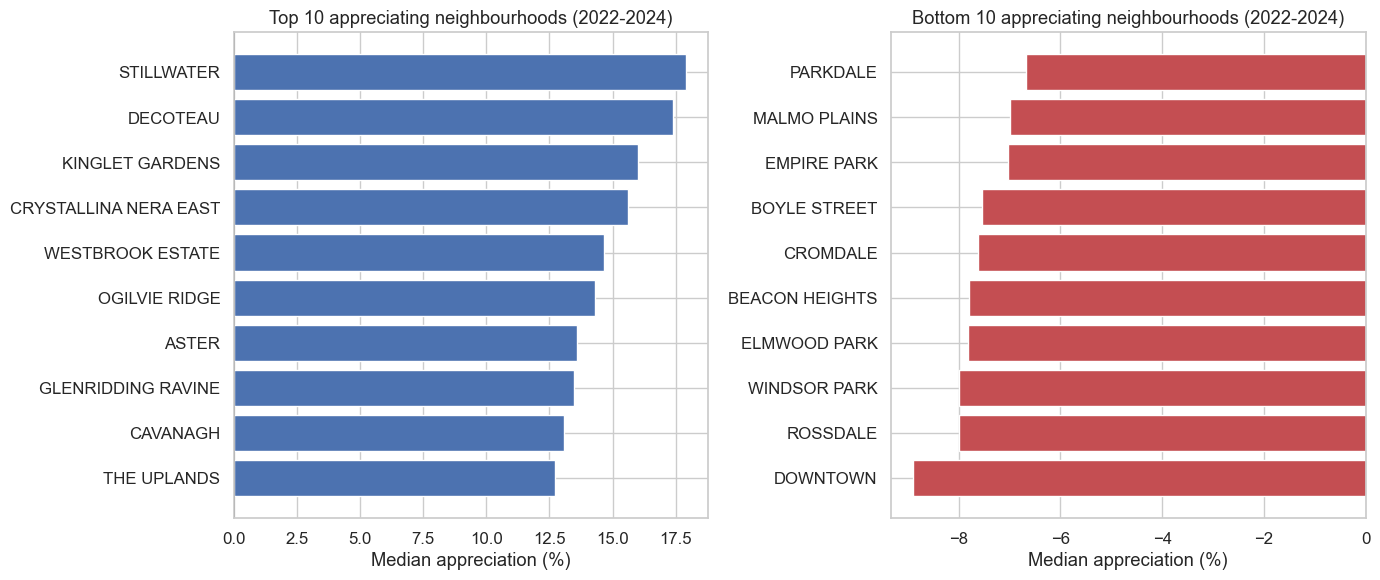

In [37]:
neighbourhood_appreciation = (
    df_appreciation
    .groupby("neighbourhood_name")["pct_change"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "median_pct", "mean": "mean_pct", "count": "n_properties"})
    .query("n_properties >= 30")  # Only stable neighbourhoods
    .sort_values("median_pct", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 appreciating
top_10_app = neighbourhood_appreciation.head(10)
colors_top = ["#4C72B0"] * 10
axes[0].barh(top_10_app.index[::-1], top_10_app["median_pct"][::-1], color=colors_top)
axes[0].set_xlabel("Median appreciation (%)")
axes[0].set_title("Top 10 appreciating neighbourhoods (2022-2024)")
axes[0].axvline(0, color="black", linewidth=0.5)

# Bottom 10
bottom_10_app = neighbourhood_appreciation.tail(10)
colors_bottom = ["#C44E52" if v < 0 else "#DD8452" for v in bottom_10_app["median_pct"][::-1]]
axes[1].barh(bottom_10_app.index[::-1], bottom_10_app["median_pct"][::-1], color=colors_bottom)
axes[1].set_xlabel("Median appreciation (%)")
axes[1].set_title("Bottom 10 appreciating neighbourhoods (2022-2024)")
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/08_neighbourhood_appreciation.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

The spread between the best and worst performing neighbourhoods is roughly
27 percentage points: Stillwater gained ~18% while Downtown lost ~9%.

**Top appreciating neighbourhoods** are almost all newer suburban developments
in south and southwest Edmonton: Stillwater, Decoteau, Kinglet Gardens,
Cavanagh, Glenridding Ravine. These are areas with recent construction,
growing amenities, and family-oriented housing stock. The 13-18% gains over
two years significantly outpace the citywide median of +2.5%.

**Bottom appreciating neighbourhoods** fall into two distinct patterns:
- **Inner-city condo areas:** Downtown (-9%), Boyle Street, Cromdale, and
  Parkdale are dense, older neighbourhoods with high concentrations of
  apartment and multi-unit properties. The apartment depreciation trend
  from the zoning analysis directly explains their decline.
- **Established mature neighbourhoods:** Windsor Park, Rossdale, and Elmwood
  Park are older, higher-value areas that may have hit a ceiling or are
  seeing assessment corrections after previous over-valuation.

This chart reinforces the north-south divide from Test 3 and adds
neighbourhood-level granularity to that finding.

### 6.3 Appreciation by zoning category

In [38]:
zoning_appreciation = (
    df_appreciation
    .merge(
        df[df["assessment_year"] == 2022][["account_number", "zoning_group"]],
        on="account_number",
        how="left",
    )
    .groupby("zoning_group")["pct_change"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "median_pct", "mean": "mean_pct", "count": "n_properties"})
    .sort_values("median_pct", ascending=False)
)

print("Appreciation by zoning category (2022-2024):")
print()
for idx, row in zoning_appreciation.iterrows():
    print(f"  {idx:<20s}  median: {row['median_pct']:>+6.2f}%  mean: {row['mean_pct']:>+6.2f}%  (n = {row['n_properties']:,.0f})")

Appreciation by zoning category (2022-2024):

  Single Family         median:  +5.31%  mean:  +4.77%  (n = 196,150)
  Row/Townhouse         median:  +0.94%  mean:  +2.29%  (n = 50,501)
  Other                 median:  -2.68%  mean:  -0.79%  (n = 35,188)
  Apartment             median:  -4.17%  mean:  -3.61%  (n = 66,192)
  Commercial            median:  -5.13%  mean:  -4.86%  (n = 669)


**Interpretation:**

Property type is a strong predictor of appreciation direction:

- **Single Family (+5.3% median):** Clear winners. Detached homes on
  individual lots gained value across the city. With 196K matched properties,
  this is the largest and most reliable group.
- **Row/Townhouse (+0.9% median):** Essentially flat. Modest gains but
  well below the single family trend.
- **Other (-2.7% median):** Mixed-use and direct control properties declined
  slightly.
- **Apartment (-4.2% median):** Lost value. Individual condo and apartment
  units depreciated while houses appreciated, creating a divergence of nearly
  10 percentage points between single family and apartment properties.
- **Commercial (-5.1% median):** Steepest decline, though the small sample
  (n = 669) means this should be interpreted cautiously.

The single family vs apartment split (+5.3% vs -4.2%) is the second most
important finding in this analysis after the north-south geographic divide.
It suggests a structural shift in Edmonton's housing market during 2022-2024,
likely driven by post-pandemic preferences for space and the impact of rising
interest rates on entry-level condo demand.

Note: The mean and median diverge for Row/Townhouse (mean +2.3% vs median
+0.9%), indicating some row housing properties saw outsized gains that
pull the average up, while the typical row house barely moved.

### 6.4 Spatial map of appreciation rates

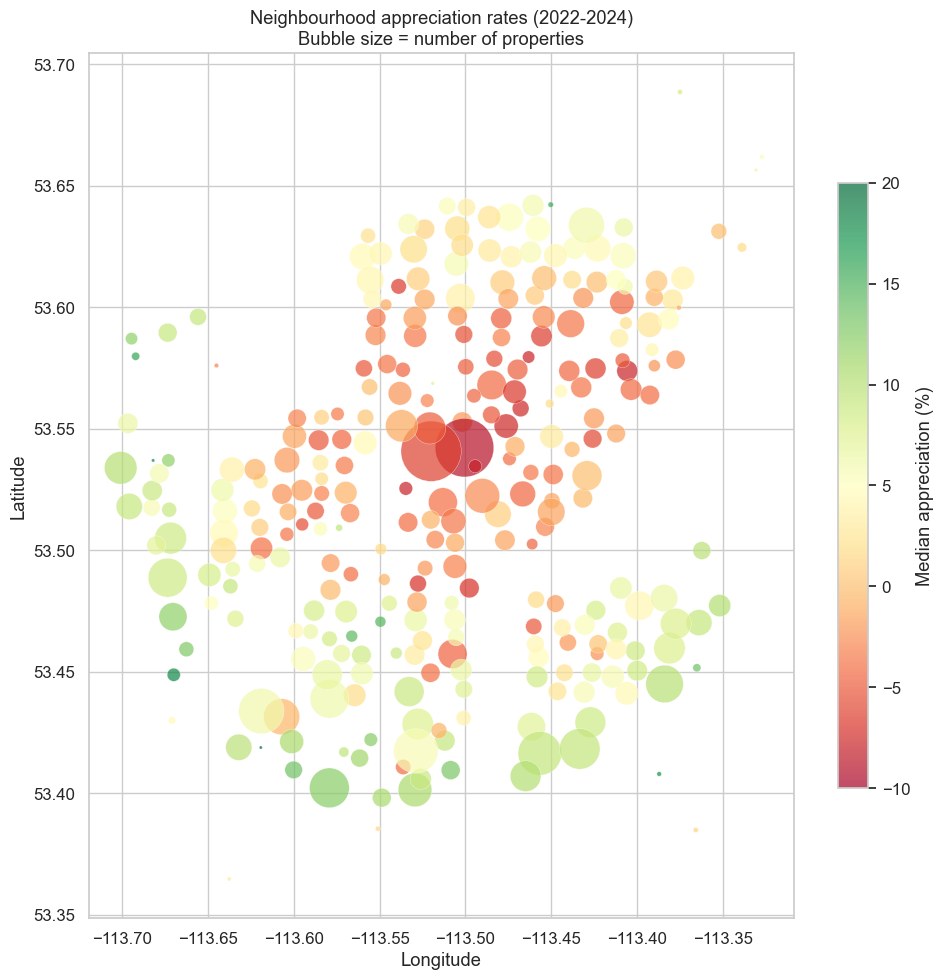

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))

# Aggregate to neighbourhood level for cleaner visualization
neighbourhood_geo = (
    df_appreciation
    .groupby("neighbourhood_name")
    .agg(
        median_pct=("pct_change", "median"),
        lat=("latitude", "median"),
        lon=("longitude", "median"),
        n=("pct_change", "count"),
    )
    .query("n >= 20")
)

scatter = ax.scatter(
    neighbourhood_geo["lon"],
    neighbourhood_geo["lat"],
    c=neighbourhood_geo["median_pct"],
    cmap="RdYlGn",
    s=neighbourhood_geo["n"] / 5, #size by number of properties
    alpha=0.7,
    edgecolors="white",
    linewidth=0.3,
    vmin=-10,
    vmax=20,
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Median appreciation (%)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Neighbourhood appreciation rates (2022-2024)\nBubble size = number of properties")

plt.tight_layout()
plt.savefig(f"{VISUALS_DIR}/09_spatial_appreciation.png", dpi=150, bbox_inches="tight")
plt.show()

The spatial bubble map now clearly shows the north-south appreciation divide:

- **South and southwest (green bubbles):** Neighbourhoods below latitude 53.50
  show consistent positive appreciation (+10% to +20%), particularly in the
  southwest quadrant near Windermere, Cavanagh, and Glenridding.
- **Central core (large red/pink bubbles):** The biggest bubbles around
  latitude 53.55 represent Downtown, Oliver, and surrounding dense
  neighbourhoods. Their size reflects high property counts (condos), and
  their red color confirms the -5% to -10% depreciation trend.
- **North (yellow/orange):** Modest or flat appreciation, consistent with
  the quadrant ANOVA results showing near-zero median change.
- **West edge (green):** Some established west-side neighbourhoods also
  show positive appreciation, suggesting the pattern is not purely
  north-south but also favors the west side of the city.

This single chart visually confirms three of the project's key findings
simultaneously: the geographic divide (Test 3), the condo depreciation
trend (zoning analysis), and the concentration of declining values in
the inner city (neighbourhood rankings).

In [43]:
neighbourhood_export = (
    df_appreciation
    .groupby("neighbourhood_name")
    .agg(
        median_appreciation=("pct_change", "median"),
        mean_appreciation=("pct_change", "mean"),
        property_count=("pct_change", "count"),
        median_value_2022=("assessed_value_2022", "median"),
        median_value_2024=("assessed_value_2024", "median"),
    )
    .reset_index()
    .query("property_count >= 50")
    .sort_values("median_appreciation", ascending=False)
)

neighbourhood_export["neighbourhood_name"] = neighbourhood_export["neighbourhood_name"].str.upper().str.strip()

neighbourhood_export.to_csv("../data/neighbourhood_appreciation.csv", index=False)

print(f"Exported {len(neighbourhood_export)} neighbourhoods")
print(f"\nTop 5:")
print(neighbourhood_export.head().to_string(index=False))
print(f"\nBottom 5:")
print(neighbourhood_export.tail().to_string(index=False))

Exported 282 neighbourhoods

Top 5:
   neighbourhood_name  median_appreciation  mean_appreciation  property_count  median_value_2022  median_value_2024
           STILLWATER                17.90              16.50             452         327,750.00         385,750.00
             DECOTEAU                17.37              18.97              56         800,000.00         942,750.00
      KINGLET GARDENS                15.99              17.96             172         490,250.00         575,750.00
CRYSTALLINA NERA EAST                15.59              16.09              77         393,000.00         465,000.00
     WESTBROOK ESTATE                14.65              16.13             307         980,500.00       1,138,500.00

Bottom 5:
neighbourhood_name  median_appreciation  mean_appreciation  property_count  median_value_2022  median_value_2024
    BEACON HEIGHTS                -7.80              -7.11            1123         261,500.00         242,000.00
      ELMWOOD PARK             

<a id="7-key-findings-and-recommendations"></a>
## 7. Key findings and recommendations

### Summary of findings

_The following findings represent statistical associations, not causal
relationships. They are based on externally observable property
characteristics available in the City of Edmonton's public assessment data._

**1. The garage "premium" is $287K raw but $116K after controls.**
Properties with garages are assessed $286,594 higher on average (95% CI:
$285K-$288K, Cohen's d = 1.44). However, the multiple regression reduces
this to $116K after controlling for lot size, zoning, age, and location.
More than half the raw gap is explained by the fact that garage properties
are predominantly detached homes on larger lots in suburban neighbourhoods.

**2. South Edmonton appreciated 6% while North Edmonton was flat.**
The clearest finding in the analysis. Southwest (+6.1% median) and
Southeast (+6.4% median) appreciated significantly more than Northwest
(-0.5%) and Northeast (-0.4%) between 2022-2024 (F = 12,809, p < 0.001).
Stillwater led at +18%, while Downtown declined -9%.

**3. Single family homes gained while apartments lost value.**
Single family properties appreciated +5.3% median, while apartments
depreciated -4.2% median, a divergence of nearly 10 percentage points.
Row/Townhouse was essentially flat at +0.9%. This suggests a structural
shift in Edmonton's housing market during 2022-2024.

**4. Zoning category significantly impacts assessed value.**
Single Family ($425K mean) > Row/Townhouse ($165K) > Apartment ($118K).
All pairwise differences are significant (ANOVA F = 35,436, p < 0.001).
These gaps are driven by lot size and building type inherent to each
zoning category.

**5. Property age is a weak standalone predictor (R-squared = 2.9%).**
Each year of age is associated with a $1,759 decrease in assessed value,
but age alone explains almost nothing. A 5-year-old condo and a 50-year-old
detached home can have similar assessments depending on location and type.

**6. External features explain 15.9% of value variance.**
The multiple regression using lot size, property age, garage, zoning, and
coordinates explains 15.9% of assessed value differences. The remaining
84.1% is attributable to interior property characteristics (square footage,
bedrooms, condition) not available in the public data. This is consistent
with expectations for an external-features-only model.

**7. Citywide appreciation is modest but significant.**
The median residential property appreciated +2.52% over two years (mean
+2.24%, t = 163.4, p < 0.001). This headline number masks wide variation
by neighbourhood (range: -9% to +18%) and property type.

---

### What this analysis does NOT claim

- Garages **cause** higher property values (association, not causation).
- Any specific neighbourhood is "overvalued" or "undervalued" (assessed
  value is the benchmark; it cannot be used to evaluate itself).
- The regression model should be used for price prediction (it is an
  inference model with known omitted variables).
- The appreciation trends observed in 2022-2024 will continue into future
  years.

---

**Analysis by Harsh Patel** | [GitHub](https://github.com/HarshP10101) |
[LinkedIn](https://www.linkedin.com/in/harsh-patel-a1563a237/)

In [41]:
print("Analysis complete. Charts saved to ../visuals/")

Analysis complete. Charts saved to ../visuals/


In [42]:
"""
Validation Tests for Edmonton Property Analysis
================================================
Run these cells after the main analysis to verify data quality,
encoding correctness, and analytical assumptions.

Add these as a new section at the end of the notebook or run them
in a separate notebook pointing to the same data.
"""

# %% [markdown]
# ## Validation Tests
#
# A set of checks to confirm data quality, encoding logic, and analytical
# assumptions before publishing the results.

# %%
passed = 0
failed = 0


def check(name: str, condition: bool, detail: str = ""):
    """Log a pass/fail result for a validation check."""
    global passed, failed
    status = "PASS" if condition else "FAIL"
    if not condition:
        failed += 1
        print(f"  [{status}] {name}")
        if detail:
            print(f"         {detail}")
    else:
        passed += 1
        print(f"  [{status}] {name}")

# %% [markdown]
# ### Test 1: Garage encoding completeness
#
# Verify that every raw garage value maps cleanly to True or False,
# and no unexpected values exist.

# %%
print("=" * 60)
print("TEST 1: Garage Encoding")
print("=" * 60)

raw_garage_values = df["garage"].unique().tolist()
print(f"  Unique raw values: {sorted([str(v) for v in raw_garage_values])}")

check(
    "Only Y, N, and NaN exist in garage column",
    set(df["garage"].dropna().unique()) == {"Y", "N"},
    f"Found unexpected values: {set(df['garage'].dropna().unique()) - {'Y', 'N'}}",
)

check(
    "has_garage is boolean type",
    df["has_garage"].dtype == bool,
    f"Actual dtype: {df['has_garage'].dtype}",
)

check(
    "has_garage True count matches garage Y count",
    df["has_garage"].sum() == (df["garage"] == "Y").sum(),
    f"has_garage True: {df['has_garage'].sum()}, garage Y: {(df['garage'] == 'Y').sum()}",
)

check(
    "No nulls in has_garage",
    df["has_garage"].isnull().sum() == 0,
    f"Null count: {df['has_garage'].isnull().sum()}",
)

# %% [markdown]
# ### Test 2: Zoning mapping coverage
#
# Check what proportion of properties land in "Other" and verify no
# large residential zoning codes are being misclassified.

# %%
print("=" * 60)
print("TEST 2: Zoning Mapping Coverage")
print("=" * 60)

other_pct = (df["zoning_group"] == "Other").mean() * 100
print(f"  'Other' category: {other_pct:.1f}% of all properties")

check(
    "Other category is below 15% of total",
    other_pct < 15,
    f"Other is {other_pct:.1f}%, which may indicate missed zoning codes",
)

# Check if any single code in "Other" has more than 5K properties
other_codes = df[df["zoning_group"] == "Other"]["zoning"].value_counts()
large_other_codes = other_codes[other_codes > 5000]

if len(large_other_codes) > 0:
    print(f"\n  Large codes still in 'Other' (>5K properties):")
    for code, count in large_other_codes.items():
        print(f"    {code}: {count:,}")

check(
    "No residential-looking codes with >5K rows in Other",
    not any(
        code.startswith(("RF", "RS", "RA", "RM", "RR", "RL", "RH"))
        for code in large_other_codes.index
    ),
    f"These codes may need remapping: {[c for c in large_other_codes.index if c.startswith(('RF','RS','RA','RM','RR','RL','RH'))]}",
)

# Verify all 5 expected groups exist
expected_groups = {"Single Family", "Row/Townhouse", "Apartment", "Commercial", "Other"}
actual_groups = set(df["zoning_group"].unique())

check(
    "All expected zoning groups are present",
    expected_groups == actual_groups,
    f"Missing: {expected_groups - actual_groups}, Extra: {actual_groups - expected_groups}",
)

# %% [markdown]
# ### Test 3: Regression dataset bias check
#
# The 2024 lot_size was 35.8% null, meaning the regression ran on a
# subset. Check whether this subset is representative.

# %%
print("=" * 60)
print("TEST 3: Regression Dataset Bias")
print("=" * 60)

df_2024_full = df[df["assessment_year"] == 2024].copy()
df_2024_with_lot = df_2024_full[df_2024_full["lot_size"].notna() & (df_2024_full["lot_size"] > 0)]

coverage = len(df_2024_with_lot) / len(df_2024_full) * 100
print(f"  2024 properties with lot_size: {len(df_2024_with_lot):,} / {len(df_2024_full):,} ({coverage:.1f}%)")

check(
    "Regression covers at least 50% of 2024 data",
    coverage >= 50,
    f"Only {coverage:.1f}% coverage, results may be biased",
)

# Compare median assessed value between included and excluded
included_median = df_2024_with_lot["assessed_value"].median()
excluded_median = df_2024_full[df_2024_full["lot_size"].isna()]["assessed_value"].median()

print(f"  Median value (included in regression): ${included_median:,.0f}")
print(f"  Median value (excluded, no lot_size):  ${excluded_median:,.0f}")
print(f"  Difference: ${included_median - excluded_median:,.0f}")

check(
    "Median value difference between included/excluded is documented",
    True,  # This is informational, always passes
    "Review the gap above. A large difference means the regression is biased toward one property type.",
)

# Compare zoning distribution
print(f"\n  Zoning distribution (included vs excluded):")
included_zoning = df_2024_with_lot["zoning_group"].value_counts(normalize=True).round(3)
excluded_zoning = df_2024_full[df_2024_full["lot_size"].isna()]["zoning_group"].value_counts(normalize=True).round(3)

for group in expected_groups - {"Commercial"}:
    inc = included_zoning.get(group, 0)
    exc = excluded_zoning.get(group, 0)
    flag = " ⚠" if abs(inc - exc) > 0.1 else ""
    print(f"    {group:<20s}  included: {inc:.1%}  excluded: {exc:.1%}{flag}")

# %% [markdown]
# ### Test 4: Appreciation calculation integrity
#
# Verify the join logic and percentage change calculation are correct.

# %%
print("=" * 60)
print("TEST 4: Appreciation Calculation Integrity")
print("=" * 60)

# Check that account_number is unique per year
for year in [2022, 2024]:
    year_df = df[df["assessment_year"] == year]
    n_total = len(year_df)
    n_unique = year_df["account_number"].nunique()
    is_unique = n_total == n_unique
    check(
        f"account_number is unique in {year}",
        is_unique,
        f"Total rows: {n_total:,}, Unique accounts: {n_unique:,}, Duplicates: {n_total - n_unique:,}",
    )

# Verify percentage change formula with a manual check
sample_row = df_appreciation.iloc[0]
manual_pct = (
    (sample_row["assessed_value_2024"] - sample_row["assessed_value_2022"])
    / sample_row["assessed_value_2022"]
    * 100
)

check(
    "Percentage change formula is correct (manual verification)",
    abs(sample_row["pct_change"] - manual_pct) < 0.001,
    f"Stored: {sample_row['pct_change']:.4f}, Manual: {manual_pct:.4f}",
)

# Check that extreme filter bounds are reasonable
pct_min = df_appreciation["pct_change"].min()
pct_max = df_appreciation["pct_change"].max()

check(
    "Appreciation values are within -50% to +100% bounds",
    pct_min >= -50 and pct_max <= 100,
    f"Range: {pct_min:.1f}% to {pct_max:.1f}%",
)

# Check matched count is reasonable
match_rate = len(df_appreciation) / len(df[df["assessment_year"] == 2024]) * 100

check(
    "At least 75% of 2024 properties matched to 2022",
    match_rate >= 75,
    f"Match rate: {match_rate:.1f}%",
)

print(f"\n  Matched: {len(df_appreciation):,} properties ({match_rate:.1f}% of 2024)")

# %% [markdown]
# ### Test 5: Statistical test assumptions
#
# Verify sample sizes are adequate and test inputs are valid.

# %%
print("=" * 60)
print("TEST 5: Statistical Test Assumptions")
print("=" * 60)

# T-test: both groups should have n > 30
garage_yes_n = (df_2024["has_garage"] == True).sum()
garage_no_n = (df_2024["has_garage"] == False).sum()

check(
    "T-test: both groups have n > 30",
    garage_yes_n > 30 and garage_no_n > 30,
    f"Garage: {garage_yes_n:,}, No garage: {garage_no_n:,}",
)

# ANOVA: all groups should have n > 30
for zoning in ["Single Family", "Row/Townhouse", "Apartment"]:
    n = len(df_2024[df_2024["zoning_group"] == zoning])
    check(
        f"ANOVA: {zoning} has n > 30",
        n > 30,
        f"n = {n:,}",
    )

# Quadrant ANOVA: all quadrants should have n > 100
for quad in ["Northwest", "Northeast", "Southwest", "Southeast"]:
    n = len(df_appreciation[df_appreciation["quadrant"] == quad])
    check(
        f"Quadrant ANOVA: {quad} has n > 100",
        n > 100,
        f"n = {n:,}",
    )

# Regression: no nulls in feature matrix
if 'X' in dir():
    null_features = X.isnull().sum()
    has_nulls = null_features.sum() > 0
    check(
        "Regression: no nulls in feature matrix",
        not has_nulls,
        f"Null counts: {null_features[null_features > 0].to_dict()}" if has_nulls else "",
    )

# %% [markdown]
# ### Test 6: Output consistency
#
# Cross-check that key numbers in the findings match the actual data.

# %%
print("=" * 60)
print("TEST 6: Output Consistency")
print("=" * 60)

# Median assessed value
actual_median = df_2024["assessed_value"].median()
check(
    f"2024 median assessed value is ${actual_median:,.0f}",
    330_000 < actual_median < 380_000,
    "Expected roughly $354K based on earlier output",
)

# Citywide appreciation
actual_appreciation_median = df_appreciation["pct_change"].median()
check(
    f"Citywide median appreciation is {actual_appreciation_median:+.2f}%",
    0 < actual_appreciation_median < 10,
    "Expected roughly +2.5% based on earlier output",
)

# Garage means
garage_yes_mean = df_2024[df_2024["has_garage"] == True]["assessed_value"].mean()
garage_no_mean = df_2024[df_2024["has_garage"] == False]["assessed_value"].mean()

check(
    "Garage mean > No garage mean",
    garage_yes_mean > garage_no_mean,
    f"Garage: ${garage_yes_mean:,.0f}, No garage: ${garage_no_mean:,.0f}",
)

# South appreciates more than North
sw_median = df_appreciation[df_appreciation["quadrant"] == "Southwest"]["pct_change"].median()
nw_median = df_appreciation[df_appreciation["quadrant"] == "Northwest"]["pct_change"].median()

check(
    "Southwest appreciation > Northwest appreciation",
    sw_median > nw_median,
    f"SW: {sw_median:+.2f}%, NW: {nw_median:+.2f}%",
)

# %% [markdown]
# ### Summary

# %%
print()
print("=" * 60)
print(f"VALIDATION COMPLETE: {passed} passed, {failed} failed")
print("=" * 60)

if failed == 0:
    print("\nAll checks passed. Safe to push to GitHub.")
else:
    print(f"\n{failed} check(s) need attention. Review the FAIL items above.")

TEST 1: Garage Encoding
  Unique raw values: ['N', 'Y']
  [PASS] Only Y, N, and NaN exist in garage column
  [PASS] has_garage is boolean type
  [PASS] has_garage True count matches garage Y count
  [PASS] No nulls in has_garage
TEST 2: Zoning Mapping Coverage
  'Other' category: 10.3% of all properties
  [PASS] Other category is below 15% of total

  Large codes still in 'Other' (>5K properties):
    DC2: 38,317
    DC1: 31,790
    HA: 7,296
    UW: 5,853
  [PASS] No residential-looking codes with >5K rows in Other
  [PASS] All expected zoning groups are present
TEST 3: Regression Dataset Bias
  2024 properties with lot_size: 242,749 / 359,998 (67.4%)
  [PASS] Regression covers at least 50% of 2024 data
  Median value (included in regression): $416,000
  Median value (excluded, no lot_size):  $157,000
  Difference: $259,000
  [PASS] Median value difference between included/excluded is documented

  Zoning distribution (included vs excluded):
    Row/Townhouse         included: 1.0%  e